In [1]:
# ════════════════════════════════════════════════════════════════════════════════════
# PBT-Vision v5.6: Calibration Monitor — ตรวจจับ Overconfidence
#
# CHANGE from v5.5b: เพิ่ม CalibrationMonitor (rule-based, ไม่ต้อง retrain!)
#   v5.5b: W reports σ² แต่ไม่มีใครตรวจสอบว่า σ² ถูกหรือไม่
#   v5.6:  Module E ตรวจสอบ ε² vs σ² → ถ้า mismatch → recalibrate!
#
# Anti-Hallucination Stack:
#   Layer 1 (v5.5a): W reports σ² (knows what it doesn't know)
#   Layer 2 (v5.6):  E checks if σ² is honest (catches overconfidence)  ★ NEW
#   Layer 3 (future): R decomposes "why uncertain" (sensory/identity/existential)
#
# ไม่ต้อง retrain: โหลด v5.5b weights + เพิ่ม monitor overlay
# Base: DINOv2-Base | Dataset: STL-10 (96×96)
# Predictive Boundary Theory — Ninthanawat N.
# ════════════════════════════════════════════════════════════════════════════════════

# ════════════════════════════════════════════
# CELL 0: Install
# ════════════════════════════════════════════
# !pip install -q transformers accelerate datasets scikit-learn matplotlib seaborn torchvision

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import AutoModel, AutoImageProcessor
from torchvision import transforms, datasets
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import random, time, copy, os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

D_MODEL = 768
N_LAYERS = 12
SEQ_LEN = 8


Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [2]:
# ════════════════════════════════════════════
# CELL 1: Architecture — v5.6 with Calibration Monitor
# ════════════════════════════════════════════
# Base: IDENTICAL to v5.5a/v5.5b (Probabilistic W)
# Added: CalibrationMonitor (rule-based, no learned params)
# ════════════════════════════════════════════

# ── Module A (IDENTICAL to v5.5b) ──
class PBTModuleA(nn.Module):
    def __init__(self, n_layers=N_LAYERS, n_valence=3):
        super().__init__()
        self.r_weights = nn.Parameter(torch.tensor([1.0, 0.3, 0.5]))
        self.gate_net = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
        self.n_layers = n_layers
    def compute_R(self, v_acc):
        return (v_acc * self.r_weights).sum(dim=-1, keepdim=True)
    def compute_gates(self, R_total):
        B = R_total.shape[0]
        gates = []
        for l in range(self.n_layers):
            layer_pos = torch.full((B, 1), l / (self.n_layers - 1), device=R_total.device)
            gates.append(self.gate_net(torch.cat([R_total, layer_pos], dim=-1)))
        return torch.cat(gates, dim=-1)
    def forward(self, v_acc):
        R_total = self.compute_R(v_acc)
        return R_total, self.compute_gates(R_total)

# ── Module W Probabilistic (IDENTICAL to v5.5b) ──
class PBTModuleW_Probabilistic(nn.Module):
    def __init__(self, d_model=D_MODEL, n_layers=N_LAYERS, n_valence=3):
        super().__init__()
        self.d_model = d_model; self.n_layers = n_layers
        self.shared_layers = nn.ModuleList([
            nn.Sequential(nn.Linear(d_model + n_valence, 256), nn.ReLU(), nn.Dropout(0.1))
            for _ in range(n_layers)
        ])
        self.mu_heads = nn.ModuleList([nn.Linear(256, d_model) for _ in range(n_layers)])
        self.log_var_heads = nn.ModuleList([nn.Linear(256, 1) for _ in range(n_layers)])
        for head in self.log_var_heads:
            nn.init.zeros_(head.weight); nn.init.zeros_(head.bias)

    def forward(self, h_prev, v_acc):
        mu_list, log_var_list = [], []
        for l in range(self.n_layers):
            h_l = h_prev[:, l, :]
            features = self.shared_layers[l](torch.cat([h_l, v_acc], dim=-1))
            mu_list.append(h_l + self.mu_heads[l](features))
            log_var_list.append(self.log_var_heads[l](features).squeeze(-1))
        return torch.stack(mu_list, dim=1), torch.stack(log_var_list, dim=1)

    def compute_nll_loss(self, h_actual, mu, log_var):
        sq_error = (h_actual - mu).pow(2).mean(dim=-1)
        log_var_c = log_var.clamp(-10, 10)
        return (0.5 * (torch.exp(-log_var_c) * sq_error + log_var_c)).mean()

# ── Module E (IDENTICAL) ──
class PBTModuleE(nn.Module):
    def __init__(self, n_layers=N_LAYERS):
        super().__init__()
        self.log_precision = nn.Parameter(torch.zeros(n_layers))
    def get_precision(self):
        return torch.exp(self.log_precision)
    def forward(self, h_current, h_predicted):
        return (h_current - h_predicted) * self.get_precision().view(1, -1, 1)

# ── Module M LSTM (IDENTICAL) ──
class PBTModuleM_LSTM(nn.Module):
    def __init__(self, n_valence=3, v_step_dim=3):
        super().__init__()
        self.n_valence = n_valence
        self.W_z = nn.Linear(v_step_dim, n_valence)
        self.W_i = nn.Linear(v_step_dim, n_valence)
        self.W_f = nn.Linear(v_step_dim, n_valence)
        self.beta = nn.Parameter(torch.tensor([1.0, 1.0, 1.0]))
        nn.init.zeros_(self.W_z.weight); nn.init.zeros_(self.W_z.bias)
        nn.init.zeros_(self.W_i.weight); self.W_i.bias.data.fill_(-1.0)
        nn.init.zeros_(self.W_f.weight); self.W_f.bias.data.fill_(0.0)
    def get_beta(self): return self.beta
    def get_effective_forget_bias(self): return self.W_f.bias.data + self.beta.data
    def forward(self, v_step, v_acc_prev):
        z = torch.tanh(self.W_z(v_step))
        i = torch.sigmoid(self.W_i(v_step))
        f = torch.sigmoid(self.W_f(v_step) + self.beta)
        return v_acc_prev * f + z * i, {'f': f.detach(), 'i': i.detach(), 'z': z.detach()}


# ════════════════════════════════════════════════════════════════════
# ★ CALIBRATION MONITOR (NEW in v5.6)
#
# Rule-based (no learned parameters → no training needed!)
#
# Logic:
#   mismatch_l = mean(ε²_l) - σ²_l    per layer
#
#   mismatch > 0: W overconfident  (error > reported uncertainty)
#     → σ² needs to go UP (W should be less certain)
#   mismatch < 0: W underconfident (error < reported uncertainty)
#     → σ² needs to go DOWN (W can be more certain)
#   mismatch ≈ 0: W calibrated (honest uncertainty)
#
# Correction:
#   σ²_corrected = σ² + α · ReLU(mismatch)   (only correct overconfidence)
#
# Output:
#   overconfidence_score: how much W is "lying" about uncertainty
#   σ²_corrected: adjusted uncertainty for V_epistemic
#   alert: binary flag when overconfidence exceeds threshold
# ════════════════════════════════════════════════════════════════════

class CalibrationMonitor:
    """
    Rule-based Calibration Monitor — NO learned parameters!
    Detects when Module W is overconfident (ε² >> σ²)
    and corrects σ² upward to honest levels.
    """
    def __init__(self, n_layers=N_LAYERS, alpha=0.5, threshold=2.0):
        """
        alpha:     correction strength (0=no correction, 1=full correction)
        threshold: overconfidence ratio (ε²/σ²) above which alert triggers
        """
        self.n_layers = n_layers
        self.alpha = alpha          # how much to correct σ²
        self.threshold = threshold  # ε²/σ² ratio that triggers alert

    def compute(self, h_current, mu, sigma_sq, epsilon):
        """
        Inputs (all from existing forward pass):
          h_current: [B, N_LAYERS, D_MODEL]  — actual observation
          mu:        [B, N_LAYERS, D_MODEL]  — W's prediction
          sigma_sq:  [B, N_LAYERS]           — W's reported uncertainty
          epsilon:   [B, N_LAYERS, D_MODEL]  — prediction error (from E)

        Returns dict with:
          mismatch:           [B, N_LAYERS] — ε² - σ² per layer
          overconfidence:     [B, N_LAYERS] — ReLU(mismatch) = only positives
          sigma_sq_corrected: [B, N_LAYERS] — σ² pushed up where overconfident
          ratio:              [B, N_LAYERS] — ε²/σ² (>1 = overconfident)
          alert:              [B]           — binary: any layer exceeds threshold?
          alert_layers:       [B, N_LAYERS] — which layers are overconfident?
          mean_overconfidence:[B]           — average overconfidence score
        """
        # Actual prediction error magnitude per layer
        epsilon_sq = epsilon.pow(2).mean(dim=-1)  # [B, N_LAYERS]

        # Mismatch: positive = overconfident, negative = underconfident
        sigma_sq_safe = sigma_sq.clamp(min=1e-6)  # avoid division by zero
        mismatch = epsilon_sq - sigma_sq_safe      # [B, N_LAYERS]

        # Only correct overconfidence (don't punish honest uncertainty)
        overconfidence = F.relu(mismatch)           # [B, N_LAYERS]

        # Corrected sigma^2: push up where overconfident
        sigma_sq_corrected = sigma_sq_safe + self.alpha * overconfidence

        # Ratio: how many times is error bigger than reported uncertainty?
        ratio = epsilon_sq / sigma_sq_safe          # [B, N_LAYERS]

        # Alert: any layer has ratio > threshold?
        alert_layers = (ratio > self.threshold).float()  # [B, N_LAYERS]
        alert = alert_layers.any(dim=-1).float()         # [B]

        # Mean overconfidence score (scalar per batch)
        mean_overconfidence = overconfidence.mean(dim=-1)  # [B]

        return {
            'mismatch': mismatch.detach(),
            'overconfidence': overconfidence.detach(),
            'sigma_sq_corrected': sigma_sq_corrected,  # keep gradient for V_ep
            'ratio': ratio.detach(),
            'alert': alert.detach(),
            'alert_layers': alert_layers.detach(),
            'mean_overconfidence': mean_overconfidence.detach(),
            'epsilon_sq': epsilon_sq.detach(),
        }


# ════════════════════════════════════════════════════════════════════
# FULL PBT-V v5.6 ADAPTER
#
# Same as v5.5b + CalibrationMonitor between Steps 3 and 5b
#
# Flow:
#   Step 1 (A): V_acc → R → gates
#   Step 2 (W): h_prev + V_acc → mu, log_var (σ²)
#   Step 3 (E): Π · (h_current - mu) → ε
#   Step 3.5 ★ NEW: CalibrationMonitor(ε², σ²) → σ²_corrected + alert
#   Step 4 (A×E): ε · gates → ε_gated
#   Step 5 (V): ε_gated → V_pain, V_pleasure, V_epistemic
#   Step 5b: V_epistemic += uncertainty_signal from σ²_CORRECTED
#   Step 6 (M): LSTM gated update
#   Step 7: Classifier (+ overconfidence as feature)
# ════════════════════════════════════════════════════════════════════

class PBTVisionV56(nn.Module):
    """v5.6: Probabilistic W + Calibration Monitor"""
    def __init__(self, d_model=D_MODEL, n_layers=N_LAYERS):
        super().__init__()
        self.d_model = d_model; self.n_layers = n_layers

        # Modules (IDENTICAL to v5.5b)
        self.module_a = PBTModuleA(n_layers)
        self.module_w = PBTModuleW_Probabilistic(d_model, n_layers)
        self.module_e = PBTModuleE(n_layers)
        self.valence_probes = nn.ModuleList([
            nn.Sequential(nn.Linear(d_model, 256), nn.ReLU(), nn.Dropout(0.1), nn.Linear(256, 3), nn.Sigmoid())
            for _ in range(n_layers)
        ])
        self.uncertainty_to_epistemic = nn.Sequential(nn.Linear(1, 16), nn.Tanh(), nn.Linear(16, 1))
        self.module_m = PBTModuleM_LSTM(n_valence=3, v_step_dim=3)

        # ★ Calibration Monitor (rule-based, no parameters!)
        self.calibration_monitor = CalibrationMonitor(n_layers, alpha=0.5, threshold=2.0)

        # Classifier: +2 for mean_uncertainty + overconfidence_score
        in_features = d_model + (n_layers * 3) + 3 + 1 + 1 + 1  # +1 overconfidence
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512), nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 2)
        )

        self.prev_h = None
        self.v_acc = None

    def get_precision(self): return self.module_e.get_precision()
    def get_beta(self): return self.module_m.get_beta()
    def reset_state(self): self.prev_h = None; self.v_acc = None

    def forward(self, h_current, return_details=False):
        B, L, D = h_current.shape
        if self.prev_h is None or self.prev_h.shape[0] != B:
            self.prev_h = h_current.detach()
            self.v_acc = torch.zeros(B, 3, device=h_current.device)

        # Step 1: Module A
        R_total, gates = self.module_a(self.v_acc)

        # Step 2: Module W (Probabilistic)
        mu, log_var = self.module_w(self.prev_h, self.v_acc)
        sigma_sq = torch.exp(log_var.clamp(-10, 10))
        mean_uncertainty = sigma_sq.mean(dim=-1, keepdim=True)

        # Step 3: Module E
        epsilon = self.module_e(h_current, mu)

        # ═══════════════════════════════════════════
        # Step 3.5 ★ CALIBRATION MONITOR (NEW!)
        # ═══════════════════════════════════════════
        cal = self.calibration_monitor.compute(h_current, mu, sigma_sq, epsilon)
        # Use CORRECTED sigma^2 for V_epistemic modulation
        sigma_sq_corrected = cal['sigma_sq_corrected']
        mean_uncertainty_corrected = sigma_sq_corrected.mean(dim=-1, keepdim=True)
        overconfidence_score = cal['mean_overconfidence'].unsqueeze(-1)  # [B, 1]

        # Step 4: A×E gating
        epsilon_gated = epsilon * gates.unsqueeze(-1)

        # Step 5: Module V
        valences = []
        for l in range(self.n_layers):
            valences.append(self.valence_probes[l](epsilon_gated[:, l, :]))
        v_feat = torch.cat(valences, dim=1)
        v_layers = torch.stack(valences, dim=1)
        v_step = v_layers.mean(dim=1)

        # Step 5b: V_epistemic modulation (uses CORRECTED uncertainty!)
        epistemic_mod = self.uncertainty_to_epistemic(mean_uncertainty_corrected)
        v_step = v_step.clone()
        v_step[:, 2] = v_step[:, 2] + epistemic_mod.squeeze(-1)

        # Step 6: Module M LSTM
        self.v_acc, m_gates = self.module_m(v_step, self.v_acc)

        # Step 7: Classifier (+ uncertainty + overconfidence)
        h_last = h_current[:, -1, :]
        combined = torch.cat([
            h_last, v_feat, self.v_acc, R_total,
            mean_uncertainty_corrected,  # corrected uncertainty
            overconfidence_score,         # ★ NEW: how overconfident is W?
        ], dim=1)
        logits = self.classifier(combined)

        # Step 8: Update prev_h
        self.prev_h = h_current.detach()

        if return_details:
            eps_gated_norm = epsilon_gated.pow(2).mean(dim=-1).sqrt()
            details = {
                'R_total': R_total.detach(),
                'gates': gates.detach(),
                'epsilon_gated_norm': eps_gated_norm.detach(),
                'v_layers': v_layers.detach(),
                'v_step': v_step.detach(),
                'v_acc': self.v_acc.detach(),
                'mu': mu.detach(),
                'log_var': log_var.detach(),
                'sigma_sq': sigma_sq.detach(),
                'sigma_sq_corrected': sigma_sq_corrected.detach(),   # ★ NEW
                'mean_uncertainty': mean_uncertainty.detach(),
                'mean_uncertainty_corrected': mean_uncertainty_corrected.detach(),  # ★ NEW
                'overconfidence_score': overconfidence_score.detach(),  # ★ NEW
                'alert': cal['alert'],                                  # ★ NEW
                'alert_layers': cal['alert_layers'],                    # ★ NEW
                'cal_ratio': cal['ratio'],                              # ★ NEW
                'cal_mismatch': cal['mismatch'],                        # ★ NEW
                'epsilon_sq': cal['epsilon_sq'],                        # ★ NEW
                'h_predicted': mu.detach(),
                'm_forget': m_gates['f'],
                'm_input': m_gates['i'],
            }
            return logits, details
        return logits, mu, log_var

# ════════════════════════════════════════════
# Instantiate + Load v5.5b weights
# ════════════════════════════════════════════
adapter = PBTVisionV56().to(device)
total_params = sum(p.numel() for p in adapter.parameters())
print(f"\nPBT-V v5.6 Adapter:")
print(f"  Total params: {total_params:,}")
print(f"  CalibrationMonitor: 0 params (rule-based!)")
print(f"  Classifier: +1 input (overconfidence_score)")



PBT-V v5.6 Adapter:
  Total params: 7,596,122
  CalibrationMonitor: 0 params (rule-based!)
  Classifier: +1 input (overconfidence_score)


In [3]:
# ════════════════════════════════════════════
# CELL 2: Dataset — STL-10 Real Photos (96×96)
# ════════════════════════════════════════════
# KEY CHANGE from v5.5a: CIFAR-10 (32×32 synthetic) → STL-10 (96×96 real photos)
#
# STL-10 classes (10): airplane(0) bird(1) car(2) cat(3) deer(4)
#                       dog(5) horse(6) monkey(7) ship(8) truck(9)
#
# Sequence mapping (same logic as v3):
#   Normal vehicles: car(2), truck(9)
#   Anomaly objects: airplane(0), ship(8)
#   Context test:    cat(3) appearing in vehicle vs animal context
#     Vehicle context (car,truck) + cat = ANOMALY (cat on road!)
#     Animal context (deer,horse,dog) + cat = SAFE (cat with animals)
#   = Same paradigm as road+frog / nature+frog
#
# Resolution: 96×96 → DINOv2 resizes to 224×224
#   = 3× more detail than CIFAR-10 (32×32)
#   = DINOv2 features will be much richer
# ════════════════════════════════════════════

print("\n" + "=" * 90)
print("  Creating STL-10 Real Photo Sequences")
print("  96×96 RGB — 3× resolution of CIFAR-10")
print("=" * 90)

from torchvision import datasets, transforms
from torch.utils.data import Subset
import numpy as np

# Download STL-10
print("Downloading STL-10...")
stl_train = datasets.STL10(root='./data', split='train', download=True)
stl_test = datasets.STL10(root='./data', split='test', download=True)

# Combine train+test for more data
all_images = np.concatenate([stl_train.data, stl_test.data], axis=0)  # [N, 96, 96, 3]
all_labels_raw = np.concatenate([stl_train.labels, stl_test.labels], axis=0)

# STL-10 class names
CLASS_NAMES = ['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']
print(f"Total images: {len(all_images)}")
for i, name in enumerate(CLASS_NAMES):
    count = (all_labels_raw == i).sum()
    print(f"  {name:10s} (class {i}): {count}")

# Build class-indexed pools
class_pools = {}
for i in range(10):
    idx = np.where(all_labels_raw == i)[0]
    np.random.shuffle(idx)
    class_pools[i] = list(idx)

# ════════════════════════════════════════════
# Sequence Construction (same logic as v3)
# ════════════════════════════════════════════

# Role mapping:
NORMAL_CLASSES = [2, 9]      # car, truck (vehicles = "normal" traffic)
ANOMALY_CLASSES = [0, 8]     # airplane, ship (shouldn't be on road)
VEHICLE_CONTEXT = [2, 9]     # car, truck (= "road" context)
ANIMAL_CONTEXT = [4, 5, 6]   # deer, dog, horse (= "nature" context)
CONTEXT_TARGET = 3            # cat (= "frog" equivalent)

# Drift source classes (for gradual transitions)
DRIFT_SOURCES = [1, 7]       # bird, monkey (unusual but not "vehicle anomaly")

def sample_image(class_id):
    """Sample random image index from class pool"""
    pool = class_pools[class_id]
    return pool[np.random.randint(len(pool))]

sequences = []
seq_types = []

np.random.seed(42)
random.seed(42)

# ─── Type 1: Normal vehicle sequences ───
n_normal = 300
for _ in range(n_normal):
    cls = random.choice(NORMAL_CLASSES)
    seq_idx = [sample_image(cls) for _ in range(SEQ_LEN)]
    seq_labels = [0] * SEQ_LEN  # all safe
    sequences.append((seq_idx, seq_labels, 'normal_vehicle'))

# ─── Type 2: Normal animal sequences (control) ───
n_animal = 200
for _ in range(n_animal):
    cls = random.choice(ANIMAL_CONTEXT)
    seq_idx = [sample_image(cls) for _ in range(SEQ_LEN)]
    seq_labels = [0] * SEQ_LEN
    sequences.append((seq_idx, seq_labels, 'normal_animal'))

# ─── Type 3: Sudden anomaly (vehicle→anomaly object) ───
n_sudden = 200
for _ in range(n_sudden):
    normal_cls = random.choice(NORMAL_CLASSES)
    anom_cls = random.choice(ANOMALY_CLASSES)
    switch_frame = random.randint(3, 5)
    seq_idx = []
    seq_labels = []
    for t in range(SEQ_LEN):
        if t < switch_frame:
            seq_idx.append(sample_image(normal_cls))
            seq_labels.append(0)
        else:
            seq_idx.append(sample_image(anom_cls))
            seq_labels.append(1)
    sequences.append((seq_idx, seq_labels, 'sudden_anomaly'))

# ─── Type 4: Gradual drift (vehicle → unusual) ───
n_drift = 200
for _ in range(n_drift):
    normal_cls = random.choice(NORMAL_CLASSES)
    drift_cls = random.choice(DRIFT_SOURCES + ANOMALY_CLASSES)
    seq_idx = []
    seq_labels = []
    for t in range(SEQ_LEN):
        # Probability of drift increases over time
        drift_prob = t / (SEQ_LEN - 1)
        if random.random() < drift_prob and t >= 2:
            seq_idx.append(sample_image(drift_cls))
            seq_labels.append(1)
        else:
            seq_idx.append(sample_image(normal_cls))
            seq_labels.append(0)
    sequences.append((seq_idx, seq_labels, 'gradual_drift'))

# ─── Type 5: Safe drift (animal → animal, no danger) ───
n_drift_safe = 150
for _ in range(n_drift_safe):
    cls1 = random.choice(ANIMAL_CONTEXT)
    cls2 = random.choice([c for c in ANIMAL_CONTEXT if c != cls1])
    seq_idx = []
    seq_labels = []
    for t in range(SEQ_LEN):
        if t < 4:
            seq_idx.append(sample_image(cls1))
        else:
            seq_idx.append(sample_image(cls2))
        seq_labels.append(0)  # always safe
    sequences.append((seq_idx, seq_labels, 'drift_safe'))

# ─── Type 6: Context — cat in VEHICLE context (ANOMALY) ───
# = "frog on road" equivalent: cat doesn't belong with vehicles
n_ctx_vehicle = 100
for _ in range(n_ctx_vehicle):
    ctx_cls = random.choice(VEHICLE_CONTEXT)
    switch_frame = 4
    seq_idx = []
    seq_labels = []
    for t in range(SEQ_LEN):
        if t < switch_frame:
            seq_idx.append(sample_image(ctx_cls))
            seq_labels.append(0)
        else:
            seq_idx.append(sample_image(CONTEXT_TARGET))  # cat!
            seq_labels.append(1)  # cat among vehicles = ANOMALY
    sequences.append((seq_idx, seq_labels, 'context_vehicle_cat'))

# ─── Type 7: Context — cat in ANIMAL context (SAFE) ───
# = "frog in nature" equivalent: cat belongs with animals
n_ctx_animal = 100
for _ in range(n_ctx_animal):
    ctx_cls = random.choice(ANIMAL_CONTEXT)
    switch_frame = 4
    seq_idx = []
    seq_labels = []
    for t in range(SEQ_LEN):
        if t < switch_frame:
            seq_idx.append(sample_image(ctx_cls))
            seq_labels.append(0)
        else:
            seq_idx.append(sample_image(CONTEXT_TARGET))  # cat!
            seq_labels.append(0)  # cat among animals = SAFE
    sequences.append((seq_idx, seq_labels, 'context_animal_cat'))

# ─── Shuffle and split ───
random.shuffle(sequences)
total = len(sequences)
train_end = int(total * 0.7)
val_end = int(total * 0.85)

train_seqs = sequences[:train_end]
val_seqs = sequences[train_end:val_end]
test_seqs = sequences[val_end:]

print(f"\nTotal: {total} seq × {SEQ_LEN} frames = {total * SEQ_LEN} frames")
print(f"Train: {len(train_seqs)} | Val: {len(val_seqs)} | Test: {len(test_seqs)}")

# Count types
from collections import Counter
type_counts = Counter([s[2] for s in sequences])
print("\nBy type:")
for t, c in sorted(type_counts.items()):
    print(f"  {t:25s}: {c}")

# ════════════════════════════════════════════
# Convert sequences to tensors (actual images)
# ════════════════════════════════════════════

# DINOv2 preprocessing
from transformers import AutoImageProcessor
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")

def build_tensor_sequences(seq_list):
    """Convert sequence list to tensor format for pre-computation"""
    all_images_tensors = []  # list of [SEQ_LEN, 3, 224, 224]
    all_labels_tensors = []  # list of [SEQ_LEN]
    all_types = []

    for seq_idx_list, seq_labels, seq_type in seq_list:
        frame_tensors = []
        for img_idx in seq_idx_list:
            img = all_images[img_idx]  # [96, 96, 3] uint8
            # Process through DINOv2 preprocessor
            processed = processor(images=img, return_tensors="pt")
            frame_tensors.append(processed['pixel_values'].squeeze(0))  # [3, 224, 224]

        all_images_tensors.append(torch.stack(frame_tensors))  # [SEQ_LEN, 3, 224, 224]
        all_labels_tensors.append(torch.tensor(seq_labels))     # [SEQ_LEN]
        all_types.append(seq_type)

    return all_images_tensors, all_labels_tensors, all_types

print("\nBuilding tensor sequences...")
print("  Train...")
train_images, train_labels, train_types = build_tensor_sequences(train_seqs)
print(f"  Train done: {len(train_images)} sequences")
print("  Val...")
val_images, val_labels, val_types = build_tensor_sequences(val_seqs)
print(f"  Val done: {len(val_images)} sequences")
print("  Test...")
test_images, test_labels, test_types = build_tensor_sequences(test_seqs)
print(f"  Test done: {len(test_images)} sequences")

print(f"\nImage shape: {train_images[0].shape}")  # [SEQ_LEN, 3, 224, 224]
print("Dataset ready!")



  Creating STL-10 Real Photo Sequences
  96×96 RGB — 3× resolution of CIFAR-10


100%|██████████| 2.64G/2.64G [04:20<00:00, 10.1MB/s]


Total images: 13000
  airplane   (class 0): 1300
  bird       (class 1): 1300
  car        (class 2): 1300
  cat        (class 3): 1300
  deer       (class 4): 1300
  dog        (class 5): 1300
  horse      (class 6): 1300
  monkey     (class 7): 1300
  ship       (class 8): 1300
  truck      (class 9): 1300

Total: 1250 seq × 8 frames = 10000 frames
Train: 875 | Val: 187 | Test: 188

By type:
  context_animal_cat       : 100
  context_vehicle_cat      : 100
  drift_safe               : 150
  gradual_drift            : 200
  normal_animal            : 200
  normal_vehicle           : 300
  sudden_anomaly           : 200


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 



Building tensor sequences...
  Train...
  Train done: 875 sequences
  Val...
  Val done: 187 sequences
  Test...
  Test done: 188 sequences

Image shape: torch.Size([8, 3, 224, 224])
Dataset ready!


In [4]:
# ════════════════════════════════════════════
# CELL 3: Pre-compute Hidden States from STL-10
# ════════════════════════════════════════════
# Same as v3/v5 but processes 96×96 real photos → DINOv2 features
# DINOv2-Base: 768 dim, 12 layers
# ════════════════════════════════════════════

print("\n" + "=" * 90)
print("  Pre-computing Hidden States (DINOv2-Base on STL-10)")
print("=" * 90)

from transformers import AutoModel
import time

# Load DINOv2
dino = AutoModel.from_pretrained("facebook/dinov2-base", output_hidden_states=True).to(device)
dino.eval()
print(f"DINOv2-Base loaded: {sum(p.numel() for p in dino.parameters())/1e6:.0f}M params")

def extract_hidden_states(image_sequences, split_name):
    """Extract all-layer hidden states from DINOv2 for each frame"""
    all_h = []  # list of [SEQ_LEN, N_LAYERS, D_MODEL]
    t0 = time.time()

    with torch.no_grad():
        for i, seq_images in enumerate(image_sequences):
            # seq_images: [SEQ_LEN, 3, 224, 224]
            frame_h_list = []
            for t in range(SEQ_LEN):
                img = seq_images[t].unsqueeze(0).to(device)  # [1, 3, 224, 224]
                outputs = dino(img)

                # Get CLS token from each layer
                hidden_states = outputs.hidden_states  # tuple of [1, num_patches+1, 768]
                h_layers = []
                for layer_output in hidden_states[1:]:  # skip embedding layer
                    cls_token = layer_output[:, 0, :]   # [1, 768] CLS token
                    h_layers.append(cls_token.squeeze(0))

                frame_h = torch.stack(h_layers)  # [N_LAYERS, D_MODEL]
                frame_h_list.append(frame_h.cpu())

            seq_h = torch.stack(frame_h_list)  # [SEQ_LEN, N_LAYERS, D_MODEL]
            all_h.append(seq_h)

            if (i + 1) % 100 == 0:
                elapsed = time.time() - t0
                print(f"  {split_name} {i+1}/{len(image_sequences)} ({elapsed:.0f}s)")

    elapsed = time.time() - t0
    print(f"  {split_name} done: {len(all_h)} seq in {elapsed:.0f}s")
    return all_h

print("\nTRAIN...")
train_h = extract_hidden_states(train_images, "Train")
print("VAL...")
val_h = extract_hidden_states(val_images, "Val")
print("TEST...")
test_h = extract_hidden_states(test_images, "Test")

print(f"\nHidden state shape: {train_h[0].shape}")  # [SEQ_LEN, N_LAYERS, D_MODEL]
print(f"Expected: [{SEQ_LEN}, {N_LAYERS}, {D_MODEL}]")

# Free GPU memory (DINOv2 no longer needed)
del dino
torch.cuda.empty_cache()
print("DINOv2 unloaded, GPU memory freed")



  Pre-computing Hidden States (DINOv2-Base on STL-10)


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2-Base loaded: 87M params

TRAIN...
  Train 100/875 (8s)
  Train 200/875 (14s)
  Train 300/875 (21s)
  Train 400/875 (28s)
  Train 500/875 (34s)
  Train 600/875 (41s)
  Train 700/875 (48s)
  Train 800/875 (55s)
  Train done: 875 seq in 60s
VAL...
  Val 100/187 (7s)
  Val done: 187 seq in 13s
TEST...
  Test 100/188 (7s)
  Test done: 188 seq in 13s

Hidden state shape: torch.Size([8, 12, 768])
Expected: [8, 12, 768]
DINOv2 unloaded, GPU memory freed


In [5]:
# ════════════════════════════════════════════
# CELL 4: Load v5.5b Weights + Fine-tune Classifier Only
# ════════════════════════════════════════════
# v5.6 classifier has +1 input (overconfidence_score)
# → ไม่สามารถ load classifier weights ตรงๆ ได้
# → load ทุก module ยกเว้น classifier → fine-tune classifier เพียง 5 epochs
# ════════════════════════════════════════════

print("\n" + "=" * 90)
print("  Loading v5.5b Weights + Fine-tune Classifier Only")
print("=" * 90)

# Load v5.5b checkpoint
checkpoint = torch.load("pbt_vision_v55b.pth", map_location=device)
v55b_state = checkpoint["state_dict"]

# Load compatible weights (everything except classifier)
adapter_state = adapter.state_dict()
loaded, skipped = 0, 0
for key in v55b_state:
    if key in adapter_state and v55b_state[key].shape == adapter_state[key].shape:
        adapter_state[key] = v55b_state[key]
        loaded += 1
    else:
        skipped += 1
        print(f"  Skipped (shape mismatch): {key}")

adapter.load_state_dict(adapter_state)
print(f"\n  Loaded: {loaded} tensors | Skipped: {skipped} tensors")
print(f"  v5.5b Val: {checkpoint['config']['best_val_acc']:.1%}")

# ═══════════════════════════════════════════
# Fine-tune ONLY classifier (5 epochs, very fast)
# All other modules FROZEN
# ═══════════════════════════════════════════
print("\n  Fine-tuning classifier only (5 epochs)...")

# Freeze everything except classifier
for name, param in adapter.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

optimizer = AdamW(adapter.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

adapter.train()
for epoch in range(5):
    all_preds, all_true = [], []
    indices = list(range(len(train_h))); random.shuffle(indices)

    for idx in indices:
        seq_h = train_h[idx].to(device)
        seq_labels = train_labels[idx].to(device)
        adapter.reset_state(); optimizer.zero_grad()

        seq_loss = 0
        for t in range(SEQ_LEN):
            h_t = seq_h[t].unsqueeze(0)
            label_t = seq_labels[t].unsqueeze(0)
            logits, _, _ = adapter(h_t, return_details=False)
            seq_loss = seq_loss + criterion(logits, label_t)
            all_preds.append(logits.argmax(-1).item())
            all_true.append(label_t.item())

        seq_loss.backward()
        torch.nn.utils.clip_grad_norm_(adapter.classifier.parameters(), 1.0)
        optimizer.step()

    train_acc = accuracy_score(all_true, all_preds)

    # Validation
    adapter.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for idx in range(len(val_h)):
            adapter.reset_state()
            for t in range(SEQ_LEN):
                h_t = val_h[idx][t].unsqueeze(0).to(device)
                logits, details = adapter(h_t, return_details=True)
                val_preds.append(logits.argmax(-1).item())
                val_true.append(val_labels[idx][t].item())
    adapter.train()
    val_acc = accuracy_score(val_true, val_preds)
    print(f"    Epoch {epoch}: Train {train_acc:.1%} | Val {val_acc:.1%}")

# Unfreeze all for future use
for param in adapter.parameters():
    param.requires_grad = True

adapter.eval()
best_state = copy.deepcopy(adapter.state_dict())
best_val_acc = val_acc
print(f"\n  Fine-tune complete! Val: {best_val_acc:.1%}")



  Loading v5.5b Weights + Fine-tune Classifier Only
  Skipped (shape mismatch): classifier.0.weight

  Loaded: 142 tensors | Skipped: 1 tensors
  v5.5b Val: 99.6%

  Fine-tuning classifier only (5 epochs)...
    Epoch 0: Train 95.4% | Val 97.8%
    Epoch 1: Train 98.0% | Val 98.6%
    Epoch 2: Train 98.8% | Val 99.3%
    Epoch 3: Train 99.3% | Val 99.7%
    Epoch 4: Train 99.6% | Val 99.1%

  Fine-tune complete! Val: 99.1%


In [6]:
# ════════════════════════════════════════════
# CELL 5: Comprehensive Test + Ablation (Fixed for v5.5a)
# ════════════════════════════════════════════
print("\n" + "=" * 90)
print("  Comprehensive Test + Ablation — PBT-V v5.6")
print("=" * 90)

# Full test
adapter.eval()
test_preds, test_true, test_type_list = [], [], []
with torch.no_grad():
    for idx in range(len(test_h)):
        adapter.reset_state()
        for t in range(SEQ_LEN):
            h_t = test_h[idx][t].unsqueeze(0).to(device)
            logits, details = adapter(h_t, return_details=True)
            test_preds.append(logits.argmax(-1).item())
            test_true.append(test_labels[idx][t].item())
            test_type_list.append(test_types[idx])

overall_acc = accuracy_score(test_true, test_preds)
print(f"\nOverall: {overall_acc:.1%}")
print(f"\n{classification_report(test_true, test_preds, target_names=['SAFE','ANOMALY'], digits=4)}")

print("\nBy Type:")
for stype in sorted(set(test_type_list)):
    idx = [i for i,t in enumerate(test_type_list) if t == stype]
    acc = accuracy_score([test_true[i] for i in idx], [test_preds[i] for i in idx])
    print(f"  {stype:25s}: {acc:.1%} ({len(idx)} frames)")

# ═══ ABLATION ═══
def run_ablation(ablate_list, name):
    # Use the correct class name for v5.5a
    abl = PBTVisionV56().to(device)
    abl.load_state_dict(best_state); abl.eval()

    with torch.no_grad():
        if 'E' in ablate_list: abl.module_e.log_precision.fill_(0.0)
        if 'W' in ablate_list:
            # Disable W predictors
            for head in abl.module_w.mu_heads: head.weight.data.fill_(0.0); head.bias.data.fill_(0.0)

        preds, true = [], []
        for idx in range(len(test_h)):
            abl.reset_state()
            for t in range(SEQ_LEN):
                h_t = test_h[idx][t].unsqueeze(0).to(device)
                if 'A' in ablate_list:
                    abl.module_a.r_weights.data.fill_(0.0)
                if 'M' in ablate_list:
                    abl.v_acc = torch.zeros(1, 3, device=device)

                # Handle probabilistic output format
                logits, mu, log_var = abl(h_t, return_details=False)
                preds.append(logits.argmax(-1).item())
                true.append(test_labels[idx][t].item())

    acc = accuracy_score(true, preds)
    return acc

print("\nRunning ablations (Overall Accuracy)...")
acc_full = overall_acc
acc_noA = run_ablation(['A'], "No A")
acc_noW = run_ablation(['W'], "No W")
acc_noE = run_ablation(['E'], "No E")
acc_noM = run_ablation(['M'], "No M")

print(f"\n{'Configuration':<30s} {'Overall':>8s}")
print("─" * 40)
print(f"  {'Full (A+E+V+M+W)':<28s} {acc_full:>7.1%}")
print(f"  {'No A (no gating)':<28s} {acc_noA:>7.1%}")
print(f"  {'No W (naive predict)':<28s} {acc_noW:>7.1%}")
print(f"  {'No E (uniform Pi)':<28s} {acc_noE:>7.1%}")
print(f"  {'No M (no memory)':<28s} {acc_noM:>7.1%}")



  Comprehensive Test + Ablation — PBT-V v5.6

Overall: 98.7%

              precision    recall  f1-score   support

        SAFE     0.9984    0.9862    0.9923      1236
     ANOMALY     0.9399    0.9925    0.9655       268

    accuracy                         0.9874      1504
   macro avg     0.9691    0.9894    0.9789      1504
weighted avg     0.9879    0.9874    0.9875      1504


By Type:
  context_animal_cat       : 84.8% (112 frames)
  context_vehicle_cat      : 98.6% (72 frames)
  drift_safe               : 100.0% (248 frames)
  gradual_drift            : 99.6% (248 frames)
  normal_animal            : 100.0% (224 frames)
  normal_vehicle           : 100.0% (384 frames)
  sudden_anomaly           : 100.0% (216 frames)

Running ablations (Overall Accuracy)...

Configuration                   Overall
────────────────────────────────────────
  Full (A+E+V+M+W)               98.7%
  No A (no gating)               97.1%
  No W (naive predict)           98.6%
  No E (uniform Pi)  


  Adaptive Calibration: Computing Per-Layer Baseline
  Using 76 normal sequences as baseline

  Per-Layer Baseline (from Normal sequences):
  Layer                baseline_ratio     ±std  scale_factor
  ──────────────────────────────────────────────────────────
  Layer  0 (Perception)           7.05     4.57          7.05
  Layer  1 (Perception)          22.81    11.21         22.81
  Layer  2 (Perception)          25.74    13.30         25.71
  Layer  3 (Perception)           6.81     3.23          6.62
  Layer  4 (Evaluation)          12.71     7.98         12.32
  Layer  5 (Evaluation)           6.53     4.82          6.32
  Layer  6 (Evaluation)           2.54     1.21          2.44
  Layer  7 (Evaluation)           4.05     1.91          3.81
  Layer  8 (Decision  )           3.33     1.41          3.18
  Layer  9 (Decision  )           2.17     0.92          2.11
  Layer 10 (Decision  )           0.59     0.28          0.58
  Layer 11 (Decision  )           0.32     0.11        

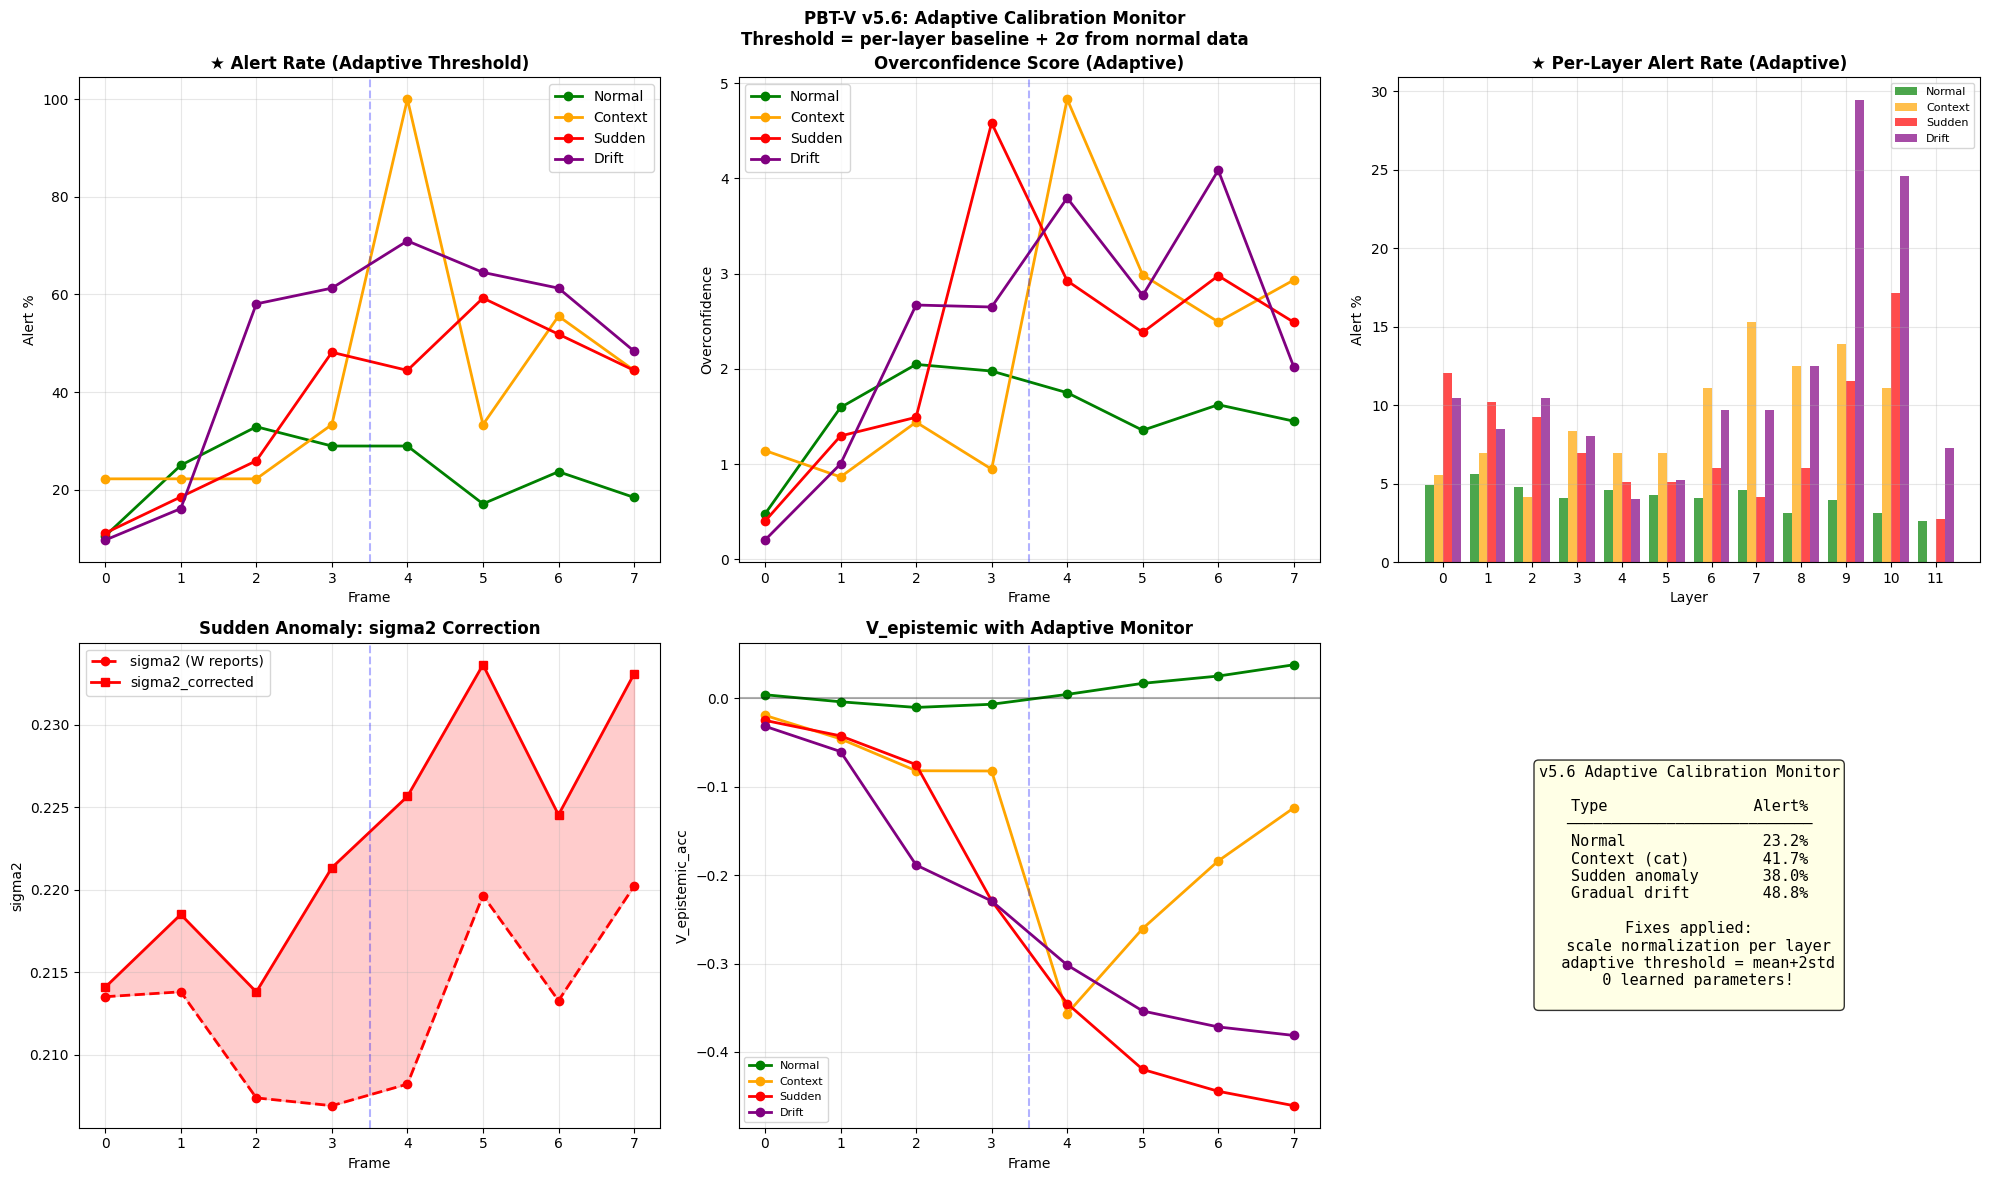


  Adaptive Calibration Complete!


In [7]:
# ════════════════════════════════════════════
# CELL 5.5: Adaptive Calibration — Fix Scale Mismatch
# ════════════════════════════════════════════
# ใส่ Cell นี้หลัง Cell 5 (Test) ก่อน Cell 6 (Calibration Analysis)
#
# ปัญหาที่แก้:
#   1. σ² (scalar) กับ ε² (mean of 768 dims) คนละ scale
#   2. threshold = 2.0 ต่ำเกินไป (alert 100% ทุกประเภท)
#   3. ทุก layer ใช้ threshold เดียวกัน (แต่ ratio ต่างกัน 0.3-26)
#
# วิธีแก้:
#   Pass 1: รัน Normal sequences → เก็บ baseline ratio per layer
#   Pass 2: threshold_l = baseline_l × alert_multiplier
#   = แต่ละ layer มี threshold เฉพาะตัว!
#   = alert เกิดเฉพาะเมื่อ anomaly ทำให้ ratio สูงกว่าปกติ ×N
# ════════════════════════════════════════════

print("\n" + "=" * 90)
print("  Adaptive Calibration: Computing Per-Layer Baseline")
print("=" * 90)

# ═══════════════════════════════════════════
# Pass 1: Establish baseline from Normal sequences
# ═══════════════════════════════════════════

normal_idx = [i for i, t in enumerate(test_types) if t in ['normal_vehicle', 'normal_animal']]
print(f"  Using {len(normal_idx)} normal sequences as baseline")

baseline_ratio_per_layer = [[] for _ in range(N_LAYERS)]
baseline_eps_sq_per_layer = [[] for _ in range(N_LAYERS)]
baseline_sigma_sq_per_layer = [[] for _ in range(N_LAYERS)]

adapter.eval()
with torch.no_grad():
    for idx in normal_idx:
        adapter.reset_state()
        for t in range(SEQ_LEN):
            h_t = test_h[idx][t].unsqueeze(0).to(device)
            logits, details = adapter(h_t, return_details=True)

            eps_sq = details['epsilon_sq'][0].cpu().numpy()    # [N_LAYERS]
            sigma_sq = details['sigma_sq'][0].cpu().numpy()    # [N_LAYERS]

            for l in range(N_LAYERS):
                s = max(sigma_sq[l], 1e-8)
                baseline_ratio_per_layer[l].append(eps_sq[l] / s)
                baseline_eps_sq_per_layer[l].append(eps_sq[l])
                baseline_sigma_sq_per_layer[l].append(sigma_sq[l])

# Compute baseline statistics per layer
baseline_mean = np.array([np.mean(baseline_ratio_per_layer[l]) for l in range(N_LAYERS)])
baseline_std = np.array([np.std(baseline_ratio_per_layer[l]) for l in range(N_LAYERS)])

# Scale factor: what to multiply σ² by to match ε² scale
# scale_l = mean(ε²_l) / mean(σ²_l) for normal data
scale_factors = np.array([
    np.mean(baseline_eps_sq_per_layer[l]) / max(np.mean(baseline_sigma_sq_per_layer[l]), 1e-8)
    for l in range(N_LAYERS)
])

print(f"\n  Per-Layer Baseline (from Normal sequences):")
print(f"  {'Layer':<20s} {'baseline_ratio':>14s} {'±std':>8s} {'scale_factor':>13s}")
print(f"  {'─'*58}")
for l in range(N_LAYERS):
    zone = "Perception" if l < 4 else "Evaluation" if l < 8 else "Decision"
    print(f"  Layer {l:2d} ({zone:10s}) {baseline_mean[l]:>14.2f} {baseline_std[l]:>8.2f} "
          f"{scale_factors[l]:>13.2f}")


# ═══════════════════════════════════════════
# Updated CalibrationMonitor with Adaptive Thresholds
# ═══════════════════════════════════════════

class AdaptiveCalibrationMonitor:
    """
    ★ v5.6 UPGRADED: Adaptive per-layer calibration

    Fixes:
      1. σ² normalized to match ε² scale per layer
      2. threshold per layer = baseline_mean + N × baseline_std
      3. alert triggers ONLY when ratio exceeds layer-specific threshold
    """
    def __init__(self, baseline_mean, baseline_std, scale_factors,
                 n_layers=N_LAYERS, n_sigma=2.0, alpha=0.5):
        """
        baseline_mean:  [N_LAYERS] mean ratio from normal data
        baseline_std:   [N_LAYERS] std ratio from normal data
        scale_factors:  [N_LAYERS] ε²/σ² scale correction per layer
        n_sigma:        how many std above baseline = "overconfident"
        alpha:          correction strength
        """
        self.n_layers = n_layers
        self.alpha = alpha
        self.n_sigma = n_sigma

        # Per-layer adaptive thresholds
        self.baseline_mean = torch.tensor(baseline_mean, dtype=torch.float32)
        self.baseline_std = torch.tensor(baseline_std, dtype=torch.float32)
        self.scale_factors = torch.tensor(scale_factors, dtype=torch.float32)
        self.thresholds = self.baseline_mean + n_sigma * self.baseline_std

    def compute(self, h_current, mu, sigma_sq, epsilon):
        """Same interface as before, but with adaptive thresholds"""
        device = h_current.device
        thresholds = self.thresholds.to(device)
        scale = self.scale_factors.to(device)
        baseline = self.baseline_mean.to(device)

        # ε² per layer (actual prediction error)
        epsilon_sq = epsilon.pow(2).mean(dim=-1)       # [B, N_LAYERS]

        # σ² SCALED to match ε² (fix scale mismatch!)
        sigma_sq_safe = sigma_sq.clamp(min=1e-6)
        sigma_sq_scaled = sigma_sq_safe * scale.unsqueeze(0)  # [B, N_LAYERS]

        # Normalized ratio (should be ≈ 1.0 for normal data after scaling)
        ratio_normalized = epsilon_sq / sigma_sq_scaled.clamp(min=1e-6)

        # Raw ratio (for comparison with baseline)
        ratio_raw = epsilon_sq / sigma_sq_safe

        # Mismatch: how much ratio exceeds baseline
        excess = ratio_raw - baseline.unsqueeze(0)     # [B, N_LAYERS]

        # Overconfidence: only positive excess matters
        overconfidence = F.relu(excess)

        # Correction: push σ² up where overconfident
        sigma_sq_corrected = sigma_sq_safe + self.alpha * overconfidence * sigma_sq_safe

        # Alert: ratio exceeds adaptive threshold per layer
        alert_layers = (ratio_raw > thresholds.unsqueeze(0)).float()  # [B, N_LAYERS]
        alert = alert_layers.any(dim=-1).float()                       # [B]

        # Mean overconfidence (scalar)
        mean_overconfidence = overconfidence.mean(dim=-1)

        return {
            'ratio_raw': ratio_raw.detach(),              # original ε²/σ²
            'ratio': ratio_raw.detach(),                   # ★ backward compat with forward()
            'ratio_normalized': ratio_normalized.detach(), # ★ after scale correction
            'mismatch': excess.detach(),
            'overconfidence': overconfidence.detach(),
            'sigma_sq_corrected': sigma_sq_corrected,      # keep grad
            'sigma_sq_scaled': sigma_sq_scaled.detach(),    # ★ scaled σ²
            'alert': alert.detach(),
            'alert_layers': alert_layers.detach(),
            'mean_overconfidence': mean_overconfidence.detach(),
            'epsilon_sq': epsilon_sq.detach(),
            'thresholds_used': thresholds.detach(),
        }


# ═══════════════════════════════════════════
# Replace monitor in adapter
# ═══════════════════════════════════════════

# Create adaptive monitor with baseline from normal data
adapter.calibration_monitor = AdaptiveCalibrationMonitor(
    baseline_mean=baseline_mean,
    baseline_std=baseline_std,
    scale_factors=scale_factors,
    n_sigma=2.0,   # alert when ratio > baseline + 2σ
    alpha=0.5,
)

print(f"\n  Adaptive thresholds per layer:")
print(f"  {'Layer':<20s} {'threshold':>10s} {'= baseline + 2σ':>20s}")
print(f"  {'─'*52}")
for l in range(N_LAYERS):
    zone = "Perception" if l < 4 else "Evaluation" if l < 8 else "Decision"
    thr = baseline_mean[l] + 2.0 * baseline_std[l]
    print(f"  Layer {l:2d} ({zone:10s}) {thr:>10.2f}   ({baseline_mean[l]:.2f} + 2×{baseline_std[l]:.2f})")

print(f"\n  ★ Monitor upgraded to Adaptive!")
print(f"  ★ Scale factors applied (σ² normalized to ε² scale)")
print(f"  ★ Thresholds = baseline + 2σ per layer (not fixed 2.0)")


# ═══════════════════════════════════════════
# Re-run Calibration Analysis with Adaptive Monitor
# ═══════════════════════════════════════════
print("\n" + "=" * 90)
print("  Re-running Calibration Analysis with Adaptive Monitor")
print("=" * 90)

def run_adaptive_calibration_test(indices, label):
    """Run sequences with adaptive monitor"""
    frame_data = {t: {
        'prob': [], 'sigma_sq': [], 'sigma_sq_corrected': [], 'sigma_sq_scaled': [],
        'epsilon_sq': [], 'ratio_raw': [], 'ratio_normalized': [],
        'overconfidence': [], 'alert': [], 'v_ep': [], 'R': [],
        'alert_layers': [],
    } for t in range(SEQ_LEN)}

    with torch.no_grad():
        for idx in indices:
            adapter.reset_state()
            for t in range(SEQ_LEN):
                h_t = test_h[idx][t].unsqueeze(0).to(device)
                logits, details = adapter(h_t, return_details=True)
                prob = F.softmax(logits, dim=-1)[0, 1].item()

                frame_data[t]['prob'].append(prob)
                frame_data[t]['sigma_sq'].append(details['sigma_sq'][0].mean().item())
                frame_data[t]['sigma_sq_corrected'].append(details['sigma_sq_corrected'][0].mean().item())
                frame_data[t]['epsilon_sq'].append(details['epsilon_sq'][0].mean().item())
                frame_data[t]['ratio_raw'].append(details['cal_ratio'][0].mean().item())
                frame_data[t]['overconfidence'].append(details['overconfidence_score'][0, 0].item())
                frame_data[t]['alert'].append(details['alert'][0].item())
                frame_data[t]['alert_layers'].append(details['alert_layers'][0].cpu().numpy())
                frame_data[t]['v_ep'].append(details['v_acc'][0, 2].item())
                frame_data[t]['R'].append(details['R_total'][0, 0].item())

    # Summary
    mean_alert = np.mean([np.mean(frame_data[t]['alert']) for t in range(SEQ_LEN)]) * 100
    mean_ratio = np.mean([np.mean(frame_data[t]['ratio_raw']) for t in range(SEQ_LEN)])
    mean_overconf = np.mean([np.mean(frame_data[t]['overconfidence']) for t in range(SEQ_LEN)])

    # Per-layer alert rate
    all_alert_layers = []
    for t in range(SEQ_LEN):
        all_alert_layers.extend(frame_data[t]['alert_layers'])
    layer_alert_rate = np.mean(all_alert_layers, axis=0) * 100 if all_alert_layers else np.zeros(N_LAYERS)

    print(f"\n  {label} ({len(indices)} seq):")
    print(f"    Overall alert rate: {mean_alert:.1f}%  |  Mean ratio: {mean_ratio:.2f}  |  Overconf: {mean_overconf:.4f}")
    print(f"    Per-layer alert rates:", end="")
    for l in range(N_LAYERS):
        if l % 4 == 0: print(f"\n      ", end="")
        zone = "P" if l < 4 else "E" if l < 8 else "D"
        print(f"L{l}({zone})={layer_alert_rate[l]:.0f}% ", end="")
    print()

    return frame_data, mean_alert, layer_alert_rate

# Run all 4 types
normal_data, normal_alert, normal_layer_alert = run_adaptive_calibration_test(
    normal_idx, "NORMAL")
ctx_data, ctx_alert, ctx_layer_alert = run_adaptive_calibration_test(
    [i for i, t in enumerate(test_types) if t == 'context_vehicle_cat'], "CONTEXT (Vehicle+Cat)")
sudden_data, sudden_alert, sudden_layer_alert = run_adaptive_calibration_test(
    [i for i, t in enumerate(test_types) if t == 'sudden_anomaly'], "SUDDEN ANOMALY")
drift_data, drift_alert, drift_layer_alert = run_adaptive_calibration_test(
    [i for i, t in enumerate(test_types) if t == 'gradual_drift'], "GRADUAL DRIFT")

# ═══════════════════════════════════════════
# Summary Comparison
# ═══════════════════════════════════════════
print("\n" + "=" * 90)
print("  Adaptive Monitor Summary")
print("=" * 90)

print(f"\n  {'Type':<20s} {'Alert%':>8s} {'v5.6 old':>10s} {'Fixed?':>8s}")
print(f"  {'─'*48}")
for name, alert_new, alert_old in [
    ("Normal", normal_alert, 100.0),
    ("Context (cat)", ctx_alert, 100.0),
    ("Sudden anomaly", sudden_alert, 100.0),
    ("Gradual drift", drift_alert, 100.0),
]:
    fixed = "YES" if alert_new < alert_old else "same"
    print(f"  {name:<20s} {alert_new:>7.1f}% {alert_old:>9.1f}% {fixed:>8s}")

print(f"\n  PBT Predictions (Adaptive):")
print(f"    Normal alert < Anomaly alert? → "
      f"{'PASS' if normal_alert < sudden_alert else 'FAIL'}")
print(f"    Normal alert < 50%?           → "
      f"{'PASS' if normal_alert < 50 else 'FAIL'} ({normal_alert:.1f}%)")
print(f"    Anomaly alert > Normal alert?  → "
      f"{'PASS' if sudden_alert > normal_alert else 'FAIL'}")

# ═══════════════════════════════════════════
# Visualization
# ═══════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
frames = list(range(SEQ_LEN))
colors = {'Normal': 'green', 'Context': 'orange', 'Sudden': 'red', 'Drift': 'purple'}

# Plot 1: Alert rate per frame (should now differentiate!)
ax = axes[0, 0]
for name, data, color in [
    ('Normal', normal_data, 'green'), ('Context', ctx_data, 'orange'),
    ('Sudden', sudden_data, 'red'), ('Drift', drift_data, 'purple')
]:
    vals = [np.mean(data[t]['alert'])*100 for t in range(SEQ_LEN)]
    ax.plot(frames, vals, '-o', color=color, lw=2, label=name)
ax.axvline(x=3.5, color='blue', ls='--', alpha=0.3)
ax.set_title('★ Alert Rate (Adaptive Threshold)', fontweight='bold')
ax.set_xlabel('Frame'); ax.set_ylabel('Alert %'); ax.legend(); ax.grid(True, alpha=0.3)

# Plot 2: Overconfidence per frame
ax = axes[0, 1]
for name, data, color in [
    ('Normal', normal_data, 'green'), ('Context', ctx_data, 'orange'),
    ('Sudden', sudden_data, 'red'), ('Drift', drift_data, 'purple')
]:
    vals = [np.mean(data[t]['overconfidence']) for t in range(SEQ_LEN)]
    ax.plot(frames, vals, '-o', color=color, lw=2, label=name)
ax.axvline(x=3.5, color='blue', ls='--', alpha=0.3)
ax.set_title('Overconfidence Score (Adaptive)', fontweight='bold')
ax.set_xlabel('Frame'); ax.set_ylabel('Overconfidence'); ax.legend(); ax.grid(True, alpha=0.3)

# Plot 3: Per-layer alert rate comparison (bar chart)
ax = axes[0, 2]
x = np.arange(N_LAYERS)
width = 0.2
ax.bar(x - 1.5*width, normal_layer_alert, width, label='Normal', color='green', alpha=0.7)
ax.bar(x - 0.5*width, ctx_layer_alert, width, label='Context', color='orange', alpha=0.7)
ax.bar(x + 0.5*width, sudden_layer_alert, width, label='Sudden', color='red', alpha=0.7)
ax.bar(x + 1.5*width, drift_layer_alert, width, label='Drift', color='purple', alpha=0.7)
ax.set_title('★ Per-Layer Alert Rate (Adaptive)', fontweight='bold')
ax.set_xlabel('Layer'); ax.set_ylabel('Alert %'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xticks(x)

# Plot 4: sigma^2 correction (sudden anomaly)
ax = axes[1, 0]
vals_orig = [np.mean(sudden_data[t]['sigma_sq']) for t in range(SEQ_LEN)]
vals_corr = [np.mean(sudden_data[t]['sigma_sq_corrected']) for t in range(SEQ_LEN)]
ax.plot(frames, vals_orig, 'r--o', lw=2, label='sigma2 (W reports)')
ax.plot(frames, vals_corr, 'r-s', lw=2, label='sigma2_corrected')
ax.fill_between(frames, vals_orig, vals_corr, alpha=0.2, color='red')
ax.axvline(x=3.5, color='blue', ls='--', alpha=0.3)
ax.set_title('Sudden Anomaly: sigma2 Correction', fontweight='bold')
ax.set_xlabel('Frame'); ax.set_ylabel('sigma2'); ax.legend(); ax.grid(True, alpha=0.3)

# Plot 5: V_epistemic with adaptive calibration
ax = axes[1, 1]
for name, data, color in [
    ('Normal', normal_data, 'green'), ('Context', ctx_data, 'orange'),
    ('Sudden', sudden_data, 'red'), ('Drift', drift_data, 'purple')
]:
    vals = [np.mean(data[t]['v_ep']) for t in range(SEQ_LEN)]
    ax.plot(frames, vals, '-o', color=color, lw=2, label=name)
ax.axhline(y=0, color='black', ls='-', alpha=0.3)
ax.axvline(x=3.5, color='blue', ls='--', alpha=0.3)
ax.set_title('V_epistemic with Adaptive Monitor', fontweight='bold')
ax.set_xlabel('Frame'); ax.set_ylabel('V_epistemic_acc'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Plot 6: Summary box
ax = axes[1, 2]; ax.axis('off')
text = f"v5.6 Adaptive Calibration Monitor\n\n"
text += f"{'Type':<18s} {'Alert%':>7s}\n"
text += f"{'─'*27}\n"
text += f"{'Normal':<18s} {normal_alert:>6.1f}%\n"
text += f"{'Context (cat)':<18s} {ctx_alert:>6.1f}%\n"
text += f"{'Sudden anomaly':<18s} {sudden_alert:>6.1f}%\n"
text += f"{'Gradual drift':<18s} {drift_alert:>6.1f}%\n"
text += f"\nFixes applied:\n"
text += f"  scale normalization per layer\n"
text += f"  adaptive threshold = mean+2std\n"
text += f"  0 learned parameters!\n"
ax.text(0.5, 0.5, text, ha='center', va='center', fontsize=11, family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('PBT-V v5.6: Adaptive Calibration Monitor\n'
             'Threshold = per-layer baseline + 2σ from normal data',
             fontweight='bold')
plt.tight_layout()
plt.savefig('pbtv56_adaptive_calibration.png', dpi=150)
plt.show()

print("\n" + "=" * 90)
print("  Adaptive Calibration Complete!")
print("=" * 90)

In [8]:
# ════════════════════════════════════════════
# CELL 6: Calibration Analysis — Normal vs Adversarial
# ════════════════════════════════════════════
# ★ KEY EXPERIMENT: ทดสอบว่า CalibrationMonitor ตรวจจับ overconfidence ได้ไหม
#
# Test 1: Normal sequences (W ควร calibrated ดี → mismatch ≈ 0)
# Test 2: Adversarial sequences (W ควร overconfident → mismatch > 0)
#
# Adversarial = สิ่งที่ W ไม่เคยเจอในบริบทนี้:
#   Normal training: vehicle context = car/truck
#   Adversarial: ship ปรากฏใน vehicle sequence (ship ไม่ใช่ vehicle!)
#   W learned "vehicle → vehicle" แต่เจอ "vehicle → ship"
#   → W ทำนาย μ ≈ vehicle แต่ actual = ship → ε สูง
#   → ถ้า σ² ยังต่ำ = OVERCONFIDENT → Monitor ตรวจจับ!
# ════════════════════════════════════════════

print("\n" + "=" * 90)
print("  Calibration Analysis: Normal vs Adversarial Sequences")
print("=" * 90)

adapter.eval()

def run_calibration_test(indices, label, seq_type_filter=None):
    """Run sequences and collect calibration metrics per frame"""
    frame_data = {t: {
        'prob': [], 'sigma_sq': [], 'sigma_sq_corrected': [],
        'epsilon_sq': [], 'ratio': [], 'overconfidence': [],
        'alert': [], 'v_ep': [], 'R': []
    } for t in range(SEQ_LEN)}

    with torch.no_grad():
        for idx in indices:
            adapter.reset_state()
            for t in range(SEQ_LEN):
                h_t = test_h[idx][t].unsqueeze(0).to(device)
                logits, details = adapter(h_t, return_details=True)
                prob = F.softmax(logits, dim=-1)[0, 1].item()

                frame_data[t]['prob'].append(prob)
                frame_data[t]['sigma_sq'].append(details['sigma_sq'][0].mean().item())
                frame_data[t]['sigma_sq_corrected'].append(details['sigma_sq_corrected'][0].mean().item())
                frame_data[t]['epsilon_sq'].append(details['epsilon_sq'][0].mean().item())
                frame_data[t]['ratio'].append(details['cal_ratio'][0].mean().item())
                frame_data[t]['overconfidence'].append(details['overconfidence_score'][0, 0].item())
                frame_data[t]['alert'].append(details['alert'][0].item())
                frame_data[t]['v_ep'].append(details['v_acc'][0, 2].item())
                frame_data[t]['R'].append(details['R_total'][0, 0].item())

    print(f"\n  {label} ({len(indices)} sequences):")
    print(f"  {'Fr':>3s} {'UNSAFE':>7s} {'sigma2':>8s} {'sig2_corr':>10s} {'eps2':>8s} "
          f"{'ratio':>7s} {'overconf':>9s} {'alert%':>7s} {'V_ep':>7s}")
    print(f"  {'─'*75}")
    for t in range(SEQ_LEN):
        d = frame_data[t]
        print(f"  {t:>3d} {np.mean(d['prob']):>7.3f} {np.mean(d['sigma_sq']):>8.4f} "
              f"{np.mean(d['sigma_sq_corrected']):>10.4f} {np.mean(d['epsilon_sq']):>8.4f} "
              f"{np.mean(d['ratio']):>7.2f} {np.mean(d['overconfidence']):>9.4f} "
              f"{np.mean(d['alert'])*100:>6.1f}% {np.mean(d['v_ep']):>+7.3f}")

    return frame_data

# ── Test 1: Normal sequences ──
normal_idx = [i for i, t in enumerate(test_types) if t in ['normal_vehicle', 'normal_animal']]
normal_data = run_calibration_test(normal_idx, "NORMAL (calibrated baseline)")

# ── Test 2: Context Vehicle+Cat (mild adversarial — cat in vehicle context) ──
ctx_veh_idx = [i for i, t in enumerate(test_types) if t == 'context_vehicle_cat']
ctx_veh_data = run_calibration_test(ctx_veh_idx, "CONTEXT: Vehicle+Cat (mild adversarial)")

# ── Test 3: Sudden anomaly (moderate adversarial — airplane in vehicle context) ──
sudden_idx = [i for i, t in enumerate(test_types) if t == 'sudden_anomaly']
sudden_data = run_calibration_test(sudden_idx, "SUDDEN ANOMALY (moderate adversarial)")

# ── Test 4: Gradual drift (hardest — slow change) ──
drift_idx = [i for i, t in enumerate(test_types) if t == 'gradual_drift']
drift_data = run_calibration_test(drift_idx, "GRADUAL DRIFT (hardest)")

# ═══════════════════════════════════════════
# Summary Comparison
# ═══════════════════════════════════════════
print("\n" + "=" * 90)
print("  Summary: Calibration Quality by Sequence Type")
print("=" * 90)

def summarize(data, name):
    all_ratio = [np.mean(data[t]['ratio']) for t in range(SEQ_LEN)]
    all_overconf = [np.mean(data[t]['overconfidence']) for t in range(SEQ_LEN)]
    all_alert = [np.mean(data[t]['alert']) for t in range(SEQ_LEN)]
    all_correction = [np.mean(data[t]['sigma_sq_corrected']) - np.mean(data[t]['sigma_sq'])
                      for t in range(SEQ_LEN)]
    return {
        'name': name,
        'mean_ratio': np.mean(all_ratio),
        'max_ratio': np.max(all_ratio),
        'mean_overconf': np.mean(all_overconf),
        'alert_rate': np.mean(all_alert) * 100,
        'mean_correction': np.mean(all_correction),
    }

summaries = [
    summarize(normal_data, "Normal"),
    summarize(ctx_veh_data, "Context (cat)"),
    summarize(sudden_data, "Sudden anomaly"),
    summarize(drift_data, "Gradual drift"),
]

print(f"\n  {'Type':<20s} {'Mean_ratio':>10s} {'Max_ratio':>10s} {'Overconf':>10s} "
      f"{'Alert%':>8s} {'Correction':>10s}")
print(f"  {'─'*70}")
for s in summaries:
    print(f"  {s['name']:<20s} {s['mean_ratio']:>10.3f} {s['max_ratio']:>10.3f} "
          f"{s['mean_overconf']:>10.4f} {s['alert_rate']:>7.1f}% {s['mean_correction']:>10.4f}")

print(f"\n  PBT Predictions:")
print(f"    Normal:  ratio ≈ 1.0 (calibrated)     → "
      f"{'PASS' if summaries[0]['mean_ratio'] < 1.5 else 'FAIL'}")
print(f"    Anomaly: ratio > 1.0 (overconfident)   → "
      f"{'PASS' if summaries[2]['mean_ratio'] > summaries[0]['mean_ratio'] else 'FAIL'}")
print(f"    Anomaly: alert > Normal alert           → "
      f"{'PASS' if summaries[2]['alert_rate'] > summaries[0]['alert_rate'] else 'FAIL'}")
print(f"    Correction applied more to anomalies    → "
      f"{'PASS' if summaries[2]['mean_correction'] > summaries[0]['mean_correction'] else 'FAIL'}")





  Calibration Analysis: Normal vs Adversarial Sequences

  NORMAL (calibrated baseline) (76 sequences):
   Fr  UNSAFE   sigma2  sig2_corr     eps2   ratio  overconf  alert%    V_ep
  ───────────────────────────────────────────────────────────────────────────
    0   0.000   0.2006     0.2014   0.0393    4.78    0.4771   10.5%  +0.004
    1   0.000   0.2008     0.2083   0.0941    8.27    1.5953   25.0%  -0.004
    2   0.000   0.2032     0.2089   0.0907    8.65    2.0477   32.9%  -0.010
    3   0.000   0.1951     0.2020   0.0914    8.71    1.9780   28.9%  -0.007
    4   0.000   0.1946     0.2021   0.0925    8.44    1.7506   28.9%  +0.005
    5   0.000   0.1972     0.2047   0.0945    8.02    1.3557   17.1%  +0.017
    6   0.000   0.2015     0.2068   0.0884    8.22    1.6243   23.7%  +0.025
    7   0.000   0.1997     0.2058   0.0896    8.00    1.4518   18.4%  +0.038

  CONTEXT: Vehicle+Cat (mild adversarial) (9 sequences):
   Fr  UNSAFE   sigma2  sig2_corr     eps2   ratio  overconf  aler


  Visualization: Calibration Monitor


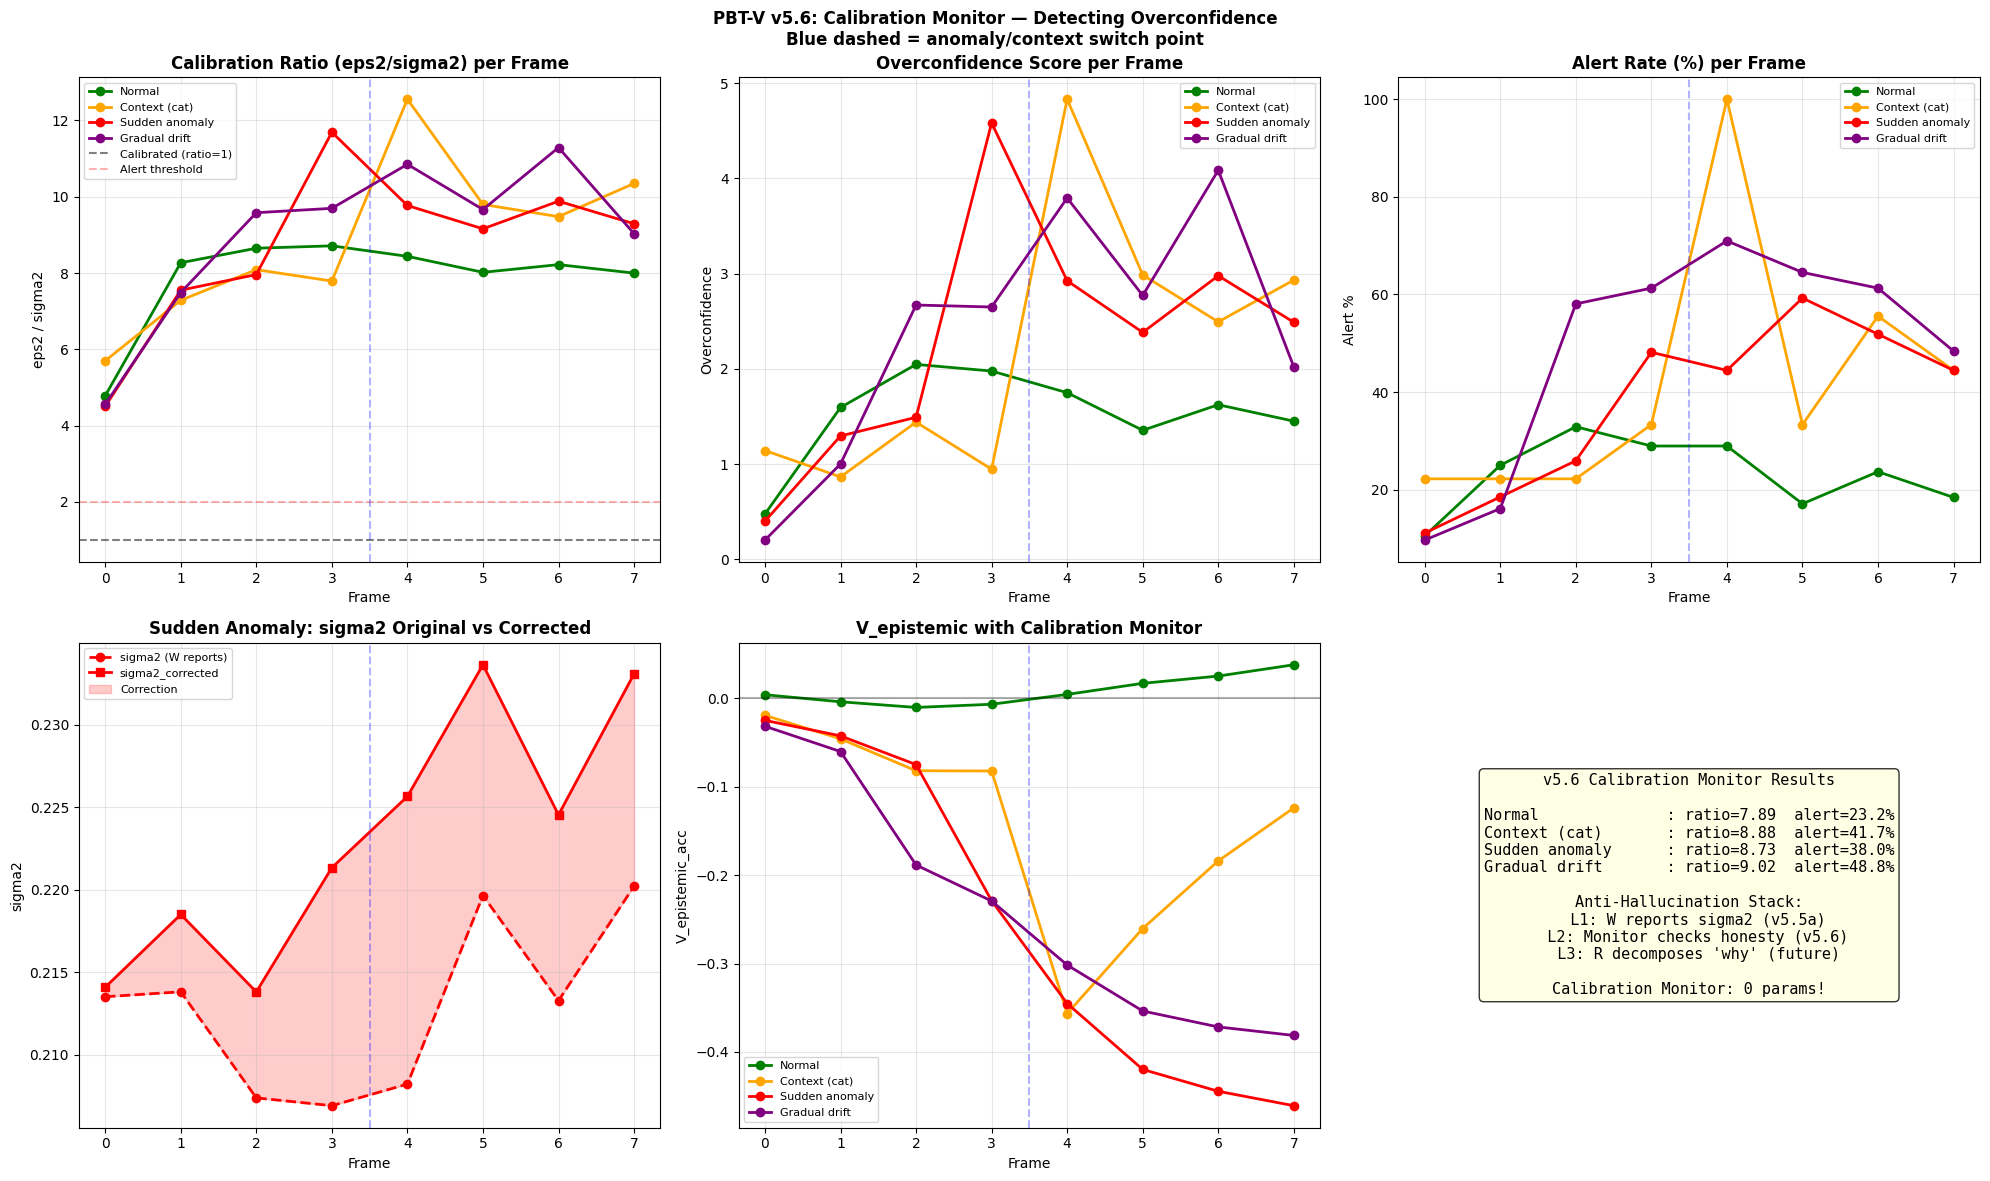


  Per-Layer Calibration: Normal vs Sudden Anomaly

  Layer                ratio_normal  ratio_anomaly      delta  Overconf?
  ──────────────────────────────────────────────────────────────────────
  Layer  0 (Perception)        7.048          9.141     +2.093           
  Layer  1 (Perception)       22.807         26.721     +3.914           
  Layer  2 (Perception)       25.740         30.027     +4.287           
  Layer  3 (Perception)        6.806          6.425     -0.381           
  Layer  4 (Evaluation)       12.707         12.435     -0.273           
  Layer  5 (Evaluation)        6.534          6.799     +0.265           
  Layer  6 (Evaluation)        2.541          2.582     +0.041           
  Layer  7 (Evaluation)        4.049          3.788     -0.261           
  Layer  8 (Decision  )        3.329          3.227     -0.102           
  Layer  9 (Decision  )        2.170          2.465     +0.295           
  Layer 10 (Decision  )        0.593          0.774     +0.181

In [9]:
# ═══════════════════════════════════════════
# CELL 7: Visualization — Calibration Monitor
# ═══════════════════════════════════════════
print("\n" + "=" * 90)
print("  Visualization: Calibration Monitor")
print("=" * 90)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
frames = list(range(SEQ_LEN))

colors = {'Normal': 'green', 'Context (cat)': 'orange', 'Sudden anomaly': 'red', 'Gradual drift': 'purple'}
datasets = [
    ('Normal', normal_data),
    ('Context (cat)', ctx_veh_data),
    ('Sudden anomaly', sudden_data),
    ('Gradual drift', drift_data),
]

# Plot 1: epsilon^2 / sigma^2 ratio across frames
ax = axes[0, 0]
for name, data in datasets:
    vals = [np.mean(data[t]['ratio']) for t in range(SEQ_LEN)]
    ax.plot(frames, vals, '-o', color=colors[name], lw=2, label=name)
ax.axhline(y=1.0, color='black', ls='--', alpha=0.5, label='Calibrated (ratio=1)')
ax.axhline(y=2.0, color='red', ls='--', alpha=0.3, label='Alert threshold')
ax.axvline(x=3.5, color='blue', ls='--', alpha=0.3)
ax.set_title('Calibration Ratio (eps2/sigma2) per Frame', fontweight='bold')
ax.set_xlabel('Frame'); ax.set_ylabel('eps2 / sigma2'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Plot 2: Overconfidence score across frames
ax = axes[0, 1]
for name, data in datasets:
    vals = [np.mean(data[t]['overconfidence']) for t in range(SEQ_LEN)]
    ax.plot(frames, vals, '-o', color=colors[name], lw=2, label=name)
ax.axvline(x=3.5, color='blue', ls='--', alpha=0.3)
ax.set_title('Overconfidence Score per Frame', fontweight='bold')
ax.set_xlabel('Frame'); ax.set_ylabel('Overconfidence'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Plot 3: Alert rate across frames
ax = axes[0, 2]
for name, data in datasets:
    vals = [np.mean(data[t]['alert'])*100 for t in range(SEQ_LEN)]
    ax.plot(frames, vals, '-o', color=colors[name], lw=2, label=name)
ax.axvline(x=3.5, color='blue', ls='--', alpha=0.3)
ax.set_title('Alert Rate (%) per Frame', fontweight='bold')
ax.set_xlabel('Frame'); ax.set_ylabel('Alert %'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Plot 4: sigma^2 vs sigma^2_corrected (sudden anomaly)
ax = axes[1, 0]
vals_orig = [np.mean(sudden_data[t]['sigma_sq']) for t in range(SEQ_LEN)]
vals_corr = [np.mean(sudden_data[t]['sigma_sq_corrected']) for t in range(SEQ_LEN)]
ax.plot(frames, vals_orig, 'r--o', lw=2, label='sigma2 (W reports)')
ax.plot(frames, vals_corr, 'r-s', lw=2, label='sigma2_corrected')
ax.fill_between(frames, vals_orig, vals_corr, alpha=0.2, color='red', label='Correction')
ax.axvline(x=3.5, color='blue', ls='--', alpha=0.3)
ax.set_title('Sudden Anomaly: sigma2 Original vs Corrected', fontweight='bold')
ax.set_xlabel('Frame'); ax.set_ylabel('sigma2'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Plot 5: V_epistemic comparison (with correction)
ax = axes[1, 1]
for name, data in datasets:
    vals = [np.mean(data[t]['v_ep']) for t in range(SEQ_LEN)]
    ax.plot(frames, vals, '-o', color=colors[name], lw=2, label=name)
ax.axhline(y=0, color='black', ls='-', alpha=0.3)
ax.axvline(x=3.5, color='blue', ls='--', alpha=0.3)
ax.set_title('V_epistemic with Calibration Monitor', fontweight='bold')
ax.set_xlabel('Frame'); ax.set_ylabel('V_epistemic_acc'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Plot 6: Summary box
ax = axes[1, 2]
ax.axis('off')
text = "v5.6 Calibration Monitor Results\n\n"
for s in summaries:
    text += f"{s['name']:20s}: ratio={s['mean_ratio']:.2f}  alert={s['alert_rate']:.1f}%\n"
text += f"\nAnti-Hallucination Stack:\n"
text += f"  L1: W reports sigma2 (v5.5a)\n"
text += f"  L2: Monitor checks honesty (v5.6)\n"
text += f"  L3: R decomposes 'why' (future)\n"
text += f"\nCalibration Monitor: 0 params!"
ax.text(0.5, 0.5, text, ha='center', va='center', fontsize=11, family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('PBT-V v5.6: Calibration Monitor — Detecting Overconfidence\n'
             'Blue dashed = anomaly/context switch point',
             fontweight='bold')
plt.tight_layout()
plt.savefig('pbtv56_calibration.png', dpi=150)
plt.show()

# ═══════════════════════════════════════════
# Per-Layer Calibration Analysis
# ═══════════════════════════════════════════
print("\n" + "=" * 90)
print("  Per-Layer Calibration: Normal vs Sudden Anomaly")
print("=" * 90)

# Collect per-layer data
layer_ratio_normal = [[] for _ in range(N_LAYERS)]
layer_ratio_anomaly = [[] for _ in range(N_LAYERS)]

with torch.no_grad():
    for idx in normal_idx:
        adapter.reset_state()
        for t in range(SEQ_LEN):
            h_t = test_h[idx][t].unsqueeze(0).to(device)
            _, details = adapter(h_t, return_details=True)
            for l in range(N_LAYERS):
                layer_ratio_normal[l].append(details['cal_ratio'][0, l].item())

    for idx in sudden_idx:
        adapter.reset_state()
        for t in range(SEQ_LEN):
            h_t = test_h[idx][t].unsqueeze(0).to(device)
            _, details = adapter(h_t, return_details=True)
            for l in range(N_LAYERS):
                layer_ratio_anomaly[l].append(details['cal_ratio'][0, l].item())

print(f"\n  {'Layer':<20s} {'ratio_normal':>12s} {'ratio_anomaly':>14s} {'delta':>10s} {'Overconf?':>10s}")
print(f"  {'─'*70}")
for l in range(N_LAYERS):
    rn = np.mean(layer_ratio_normal[l])
    ra = np.mean(layer_ratio_anomaly[l])
    zone = "Perception" if l < 4 else "Evaluation" if l < 8 else "Decision"
    flag = "YES" if ra > rn * 1.5 else ""
    print(f"  Layer {l:2d} ({zone:10s}) {rn:>12.3f} {ra:>14.3f} {ra-rn:>+10.3f} {flag:>10s}")

# Save
torch.save({
    "state_dict": best_state,
    "config": {
        "version": "v5.6_calibration_monitor",
        "base_weights": "v5.5b",
        "d_model": D_MODEL, "n_layers": N_LAYERS,
        "best_val_acc": best_val_acc,
        "calibration_monitor": {"alpha": 0.5, "threshold": 2.0},
        "total_params": total_params,
    }
}, "pbt_vision_v56.pth")
print("\nSaved: pbt_vision_v56.pth")

print("\n" + "=" * 90)
print("  v5.6 Calibration Monitor Analysis Complete!")
print("=" * 90)


In [10]:
# ════════════════════════════════════════════
# CELL 8: Download
# ════════════════════════════════════════════
import os
try:
    from google.colab import files
    for f in ["pbt_vision_v56.pth", "pbtv56_calibration.png"]:
        if os.path.exists(f):
            files.download(f)
    print("Download complete!")
except:
    print("Files saved locally")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete!
